# 004: Grain Mapping

Written by Jean-Baptiste Jacob

Last updated: 19/02/2026

### Map grains & grain boundaries using misorientation threshold 
Local indexing fits the unit cell and orientation over each pixel in a similar fashion as EBSD mapping. Post-processing is then needed to map grains and compute grain properties like the intra-granular misorientation, kernel average misorientation, etc. 

This tutorial series includes two methods to retrieve grain boundaries and segment the grains, one based on a misorientation threshold and the other one based on identification of clusters in orientation space using density-based clustering (DBSCAN). The latter is introduced in another notebook (`Tuto_004b_Grain_Mapping_DBSCAN`). Alternatively, it is possible to do this post-processing in MTex. For that, the PixelMap needs to be converted to a an ImageD11 TensorMap and then exported to a MTex .ctf file. This procedure will be briefly explained in the last section of this notebook.   

The threshold-based technique is the most straightforward and works relatively well in most of the cases, including samples with many grains (>1000), but may fail in case of grains with large plastic deformation gradients and is not developped for 3D volumes. The density-based clustering technique works better with a small number of grains (it becomes quite inefficient andf slow for very large maps) but can be easily extended to 3D grain maps or time series where the goal is to track the same grain over multiple time steps (e.g. when doing deformation or recrystallization experiments).  

### Load packages

In [1]:
import sys

# python environment stuff
IMAGED11_PATH = '/home/esrf/jean1994b'  # None means do not use git, otherwise enter the name of the folder to use for the git checkout "ImageD11" or "ImageD11_version_xx", etc
CHECKOUT_PATH = 'ImageD11'  # the name of the git checkout folder within path. None means guess


if IMAGED11_PATH is not None:
    if '/data/id11/nanoscope' not in sys.path:
        sys.path.append('/data/id11/nanoscope')
    import install_ImageD11_from_git
    install_ImageD11_from_git.setup_ImageD11_from_git(IMAGED11_PATH,CHECKOUT_PATH)

# Setting path via: 
sys.path.insert(0, /home/esrf/jean1994b/ImageD11 )
# Running from: /home/esrf/jean1994b/ImageD11/ImageD11/__init__.py


In [4]:
# general modules
import os
import numpy as np
import matplotlib.pyplot as pl
from tqdm import tqdm

# ImageD11 + point-fit 3dxrd module
import ImageD11.grain
import ImageD11.columnfile
import ImageD11.sinograms.dataset
from pf3dxrd.pf3dxrd import utils, pixelmap, crystal_structure, orientation, peak_mapping, friedel_pairs

%matplotlib ipympl
%load_ext autoreload
%autoreload 2

### Load data
For now we need only the Pixelmap. We will also need the peakfile later, to refine the average grain orientations once they are segmented. For this tutorial, pre-indexed maps are available for each demo sample, labeled `*xmap_indexed.h5`, where multiple phases have been indexed. For `SI3`, quartz, K-feldspar (orthoclase), and magnetite have been indexed. For `C18A_01`, quartz and garnet have been indexed.

In [76]:
# paths
data_dir = '/home/esrf/jean1994b/test_datasets/SI3/'
#data_dir = '/home/esrf/jean1994b/test_datasets/C18A_01_z180/'

dsname = 'SI3_DT360Z5480'
#dsname = 'C18A_01_z180'

parfile= data_dir+'/SI3.par'
#parfile= data_dir+'/C18A_01.par'


In [77]:
def load_xmap(dsname):
    xmap_file = os.path.join(data_dir, f'{dsname}_xmap.h5')  
    xmap = pixelmap.load_from_hdf5(xmap_file)
    print(xmap)
    return xmap

def load_cf(dsname):
    peakfile = os.path.join(data_dir, f'{dsname}_pk2d_p_flt.h5')   
    dsfile = os.path.join(data_dir, f'{dsname}_dataset.h5')
    ds = ImageD11.sinograms.dataset.load(dsfile)
    
    cf = ImageD11.columnfile.columnfile(peakfile)
    cf.parameters.loadparameters(parfile)
    friedel_pairs.update_geometry_fpairs(cf, ds)
    # add pixel labeling to cf + sort by pixel index

    if not cf.sortedby == 'xyi':
        print('sorting peakfile by "xyi"...')
        cf.sortby('xyi')
        
    return cf 

In [78]:
xmap = load_xmap(dsname)

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id', 'Npks', 'U', 'UBI', 'completeness', 'drlv2', 'indx_completeness', 'nindx', 'phase_label_confidence', 'uniqueness', 'unitcell'], 
 grains: 0


Let's have a look at orientation maps. 

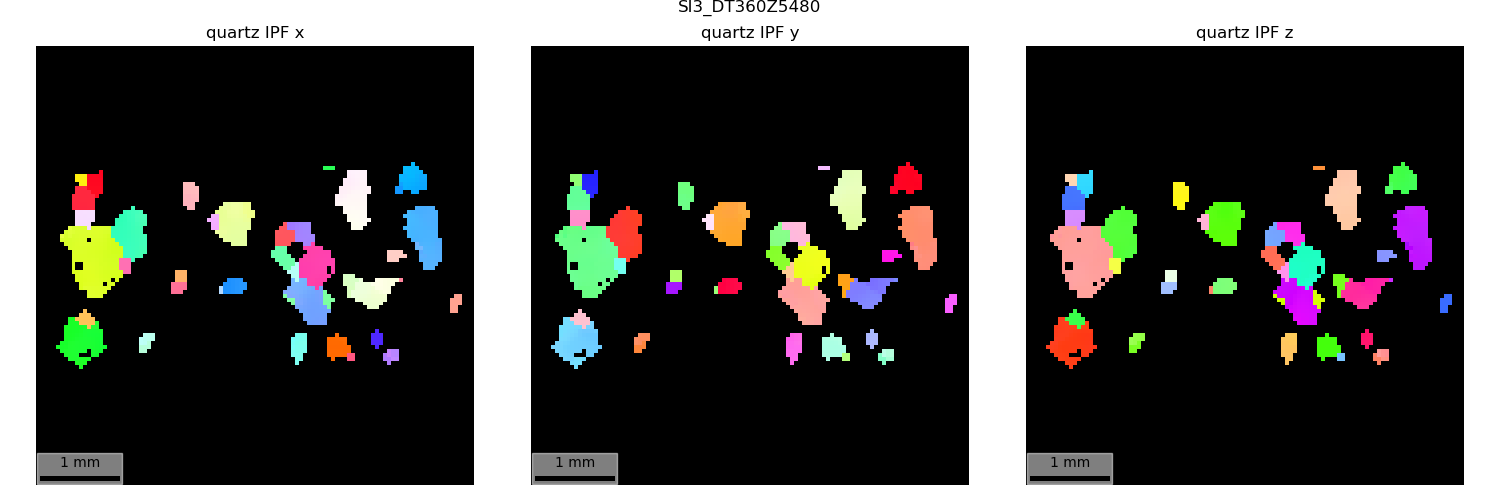

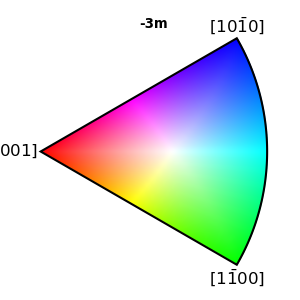

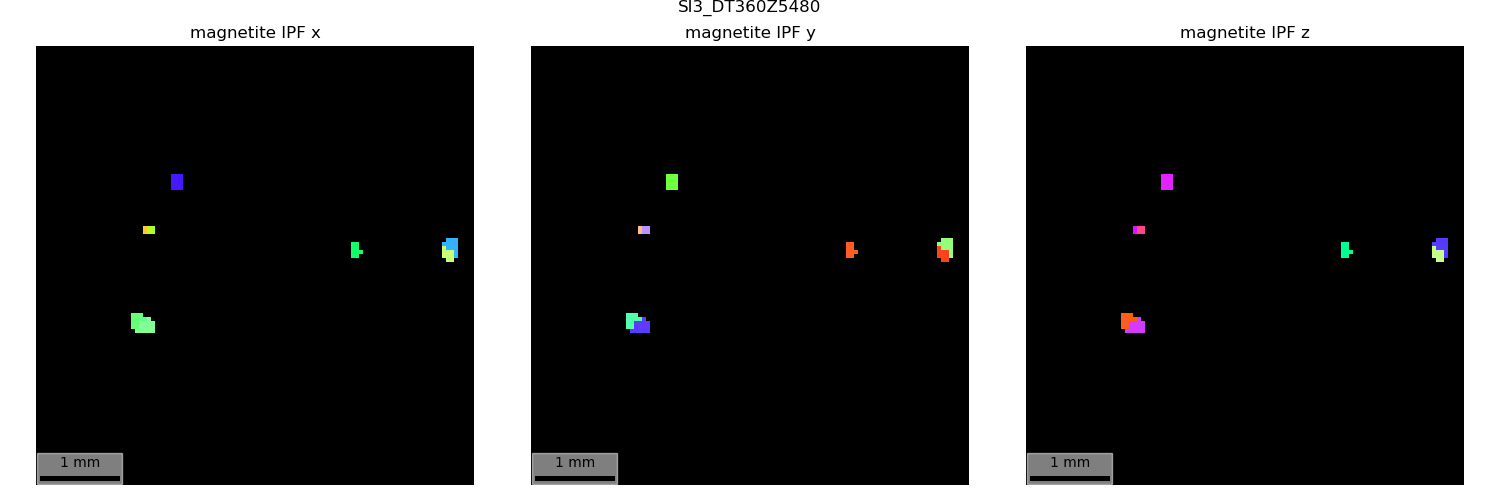

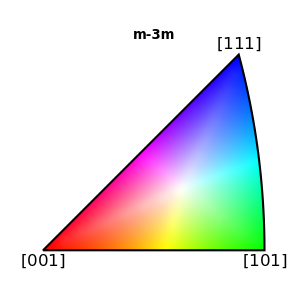

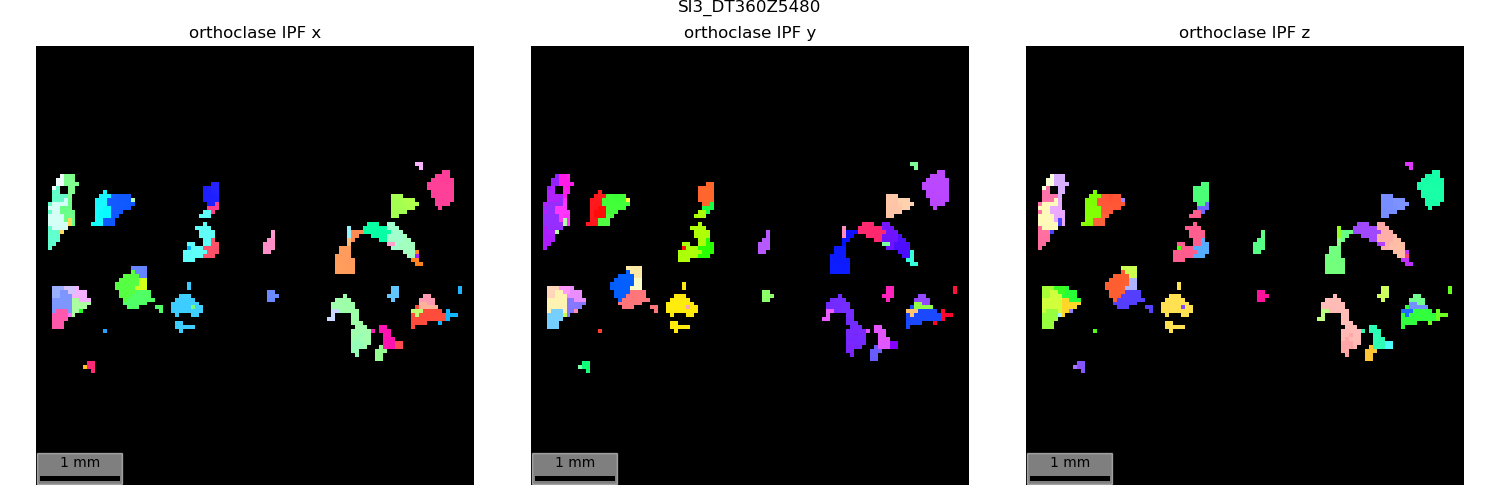

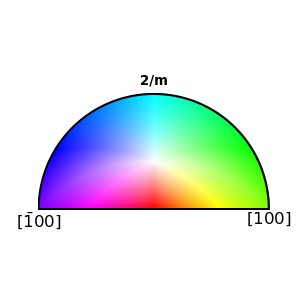

In [84]:
# plot orientation maps to have a look 
for pname in xmap.phases.pnames:
    # skip non-indexed phases
    pm = xmap.get_phase_mask(pname)
    if (pname =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue

    xmap.plot_ipf_orientation(phase=pname, ipf_directions='xyz', show_color_key=True)

### Map grain boundaries and label grains
The function `calcGrains` finds grain boundaries and does grain segmentation based on misorientation threshold. Similar conceptually to MTEX's calcGrains. It computes first the maximal misorientation with pixel neighbors (left-right and top-bottom) over the whole map and defines a grain boundary mask based on an angular threshold specified in input. Grains are then segmented by doing connected component analysis on the binary grain boundary mask. Let's try on quartz:

In [85]:
xmap.calcGrains('quartz', threshold_deg=5, min_grain_size=3)
print(xmap)

Identified 32 grains for phase 'quartz'
Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id', 'Npks', 'U', 'UBI', 'completeness', 'drlv2', 'indx_completeness', 'nindx', 'phase_label_confidence', 'uniqueness', 'unitcell', 'gb_quartz', 'gb_misorientation_quartz'], 
 grains: 0


We see two additional columns in xmap: `gb_quartz` and `gb_misorientation_quartz`, which correspond to the grain boundary mask and the misorientation maps in grain boundary pixels, respectively.

The grain_id column has also been labeled with each grain, so we can plot the labeled grain map. Note that grain boundary pixels are not asssigned to any grain and are kept at defualt value (-1).

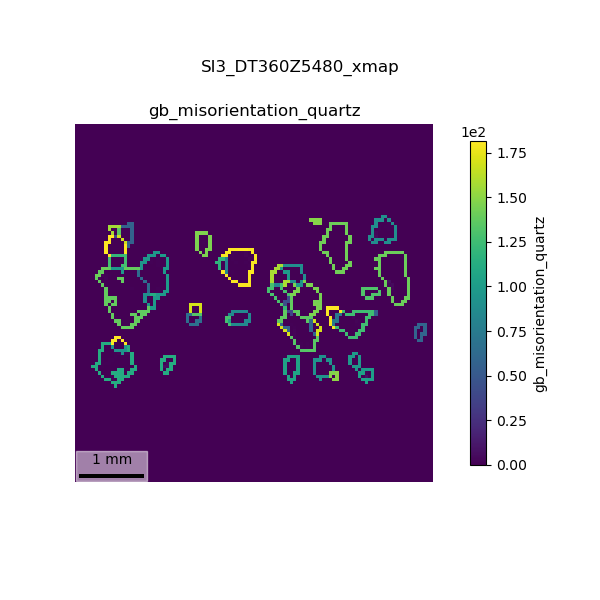

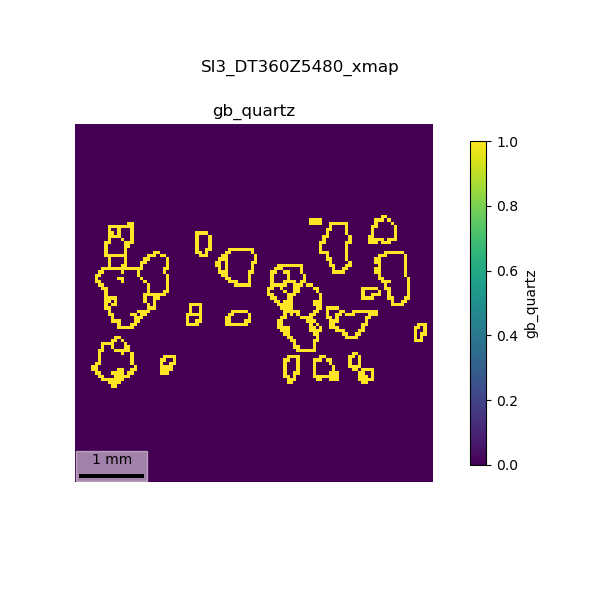

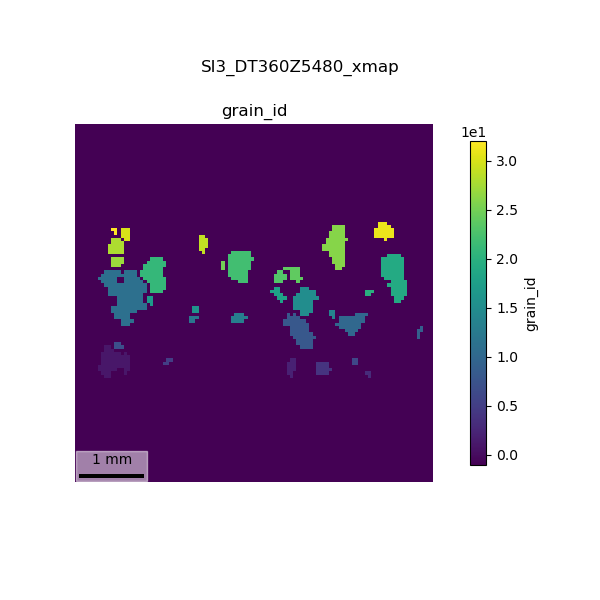

In [86]:
for key in ['gb_misorientation_quartz', 'gb_quartz', 'grain_id']:
    xmap.plot(key, autoscale=False)

We can re-do the same but this time we loop over every indexed phase. New columns `gb_<phase>` and `gb_misorientation_<phase>` are created for each phase. `grain_id` is updated for each new phase with new grain labels. 

In [92]:
# loop over each phase and mpa grain boundaries
xmap.grain_id = np.full(xmap.grain_id.shape, -1)  # initialize grain_id

for phase in xmap.phases.pnames:
    # skip non-indexed phases
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue 
    xmap.calcGrains(phase, threshold_deg=5, min_grain_size=2)

Identified 35 grains for phase 'quartz'
Identified 6 grains for phase 'magnetite'
Identified 40 grains for phase 'orthoclase'


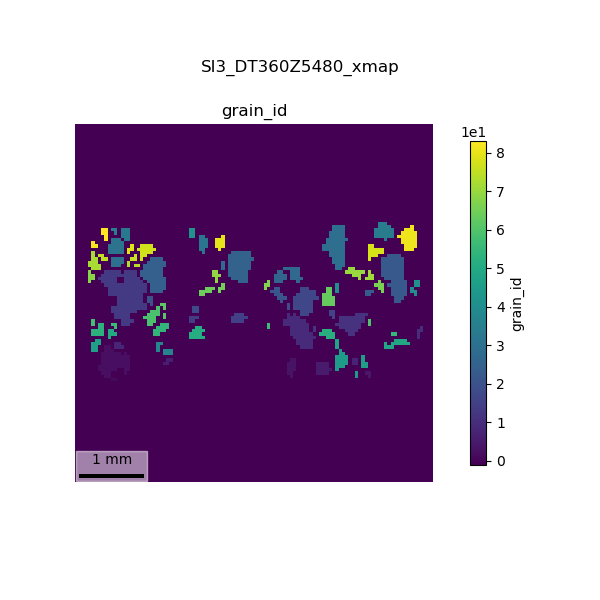

In [93]:
xmap.plot('grain_id')

In [94]:
np.unique(xmap.grain_id)

array([-1,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
       70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83])

There is an option for adding grain boundaries masks over xmap plots, by setting `show_gb = True`. This works for every data column, including also the ipf orientation maps. To use it, you must select a phase to plot. There are also two other parameters to control grain boundary aspect:
- `gb_color` : grain boundary color
- `gb_res_fact` : resolution factor; increases the grid size for the grain boundary mask -> makes thinner grain boundaries

If no grain boundary has been computed, it will try to compute them on the fly using default parameters in calcGrains.

Note: it is possible to add multiple grain boundaries (from different 'gb' columns) using the `add_grain_boundaries` method on an existing plot (see below)

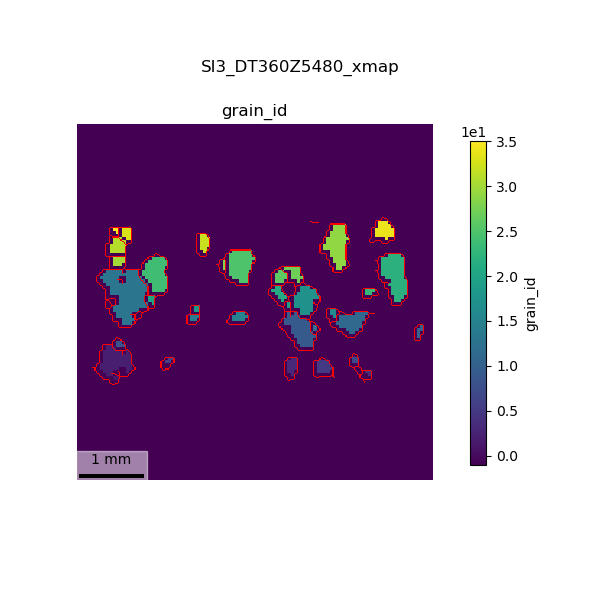

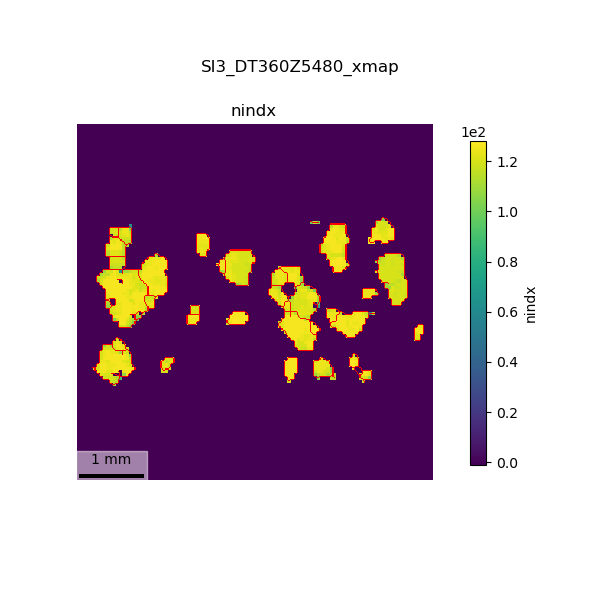

In [97]:
for key in ['grain_id', 'nindx']:
    xmap.plot(key, phase='quartz', show_gb=True, gb_color='r', gb_res_fact=3)    

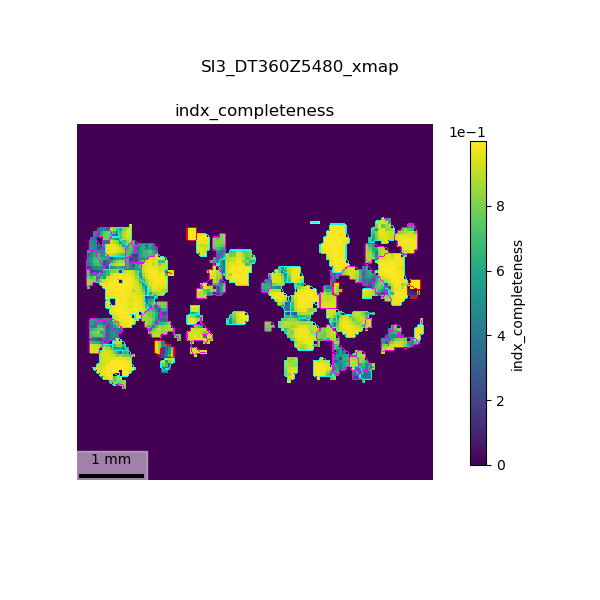

In [103]:
gb_col = ['none','cyan','r','lime','fuchsia']

fig = xmap.plot('indx_completeness', out=True)
for i, phase in enumerate(xmap.phases.pnames):
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue 
    xmap.add_grain_boundaries(phase, ax=fig.axes[0], gb_color=gb_col[i], resolution_factor=3)

We see that some low-angle grain boundaries visible in the `nindx` and `indx_completeness` maps are ignored. If you wish to segment these sub-grains, simply lower the angle threshold in calcGrains until all boundaries have been mapped.

#### FOR NOISY MAPS: Denoise orientation map

There is a (very basic) denoising function in `pf3dxrd/orientation` to get smoother grain boundaries (can help for grain mapping)

run the following cells for each phase to denoise -> will store smoothed orientation in U_smooth array 

**WARNING!!!** Make sure to write smoothed orientation in separate arrays (otherwise it will overwrite pre-indexed U column)

In [104]:
phase_to_denoise = 'quartz'

cs = xmap.phases.get(phase_to_denoise)
sym = cs.orix_phase.point_group.laue
nx, xb = xmap.grid.nx, xmap.grid.xbins

U = xmap.U.reshape(nx,nx,3,3)
pm = (xmap.phase_id == cs.phase_id)

In [105]:
# smoothing: compute new orientation array U_smooth. smoothing is done by averaging orientation in the local neighborhood of each pixel.
# kernel_size and threshold_deg control pixel neighbour selection: kernel_size:increases selection window; threshold_deg: excludes neighbors with too large misorientation
U_smooth = orientation.local_orientation_smooth_orix(U, sym, kernel_size=3, threshold_deg=10, global_mask = pm.reshape(nx,nx))

 66%|██████▌   | 71/108 [00:00<00:00, 101.41it/s]/cvmfs/hpc.esrf.fr/software/packages/linux/x86_64/jupyter-slurm/2025.04.5/envs/jupyter-slurm/lib/python3.12/site-packages/orix/quaternion/_conversions.py:1158: ComplexWarning: Casting complex values to real discards the imaginary part
  qu2d = qu2d.astype(np.float64)
100%|██████████| 108/108 [00:00<00:00, 154.06it/s]


Identified 32 grains for phase 'quartz'


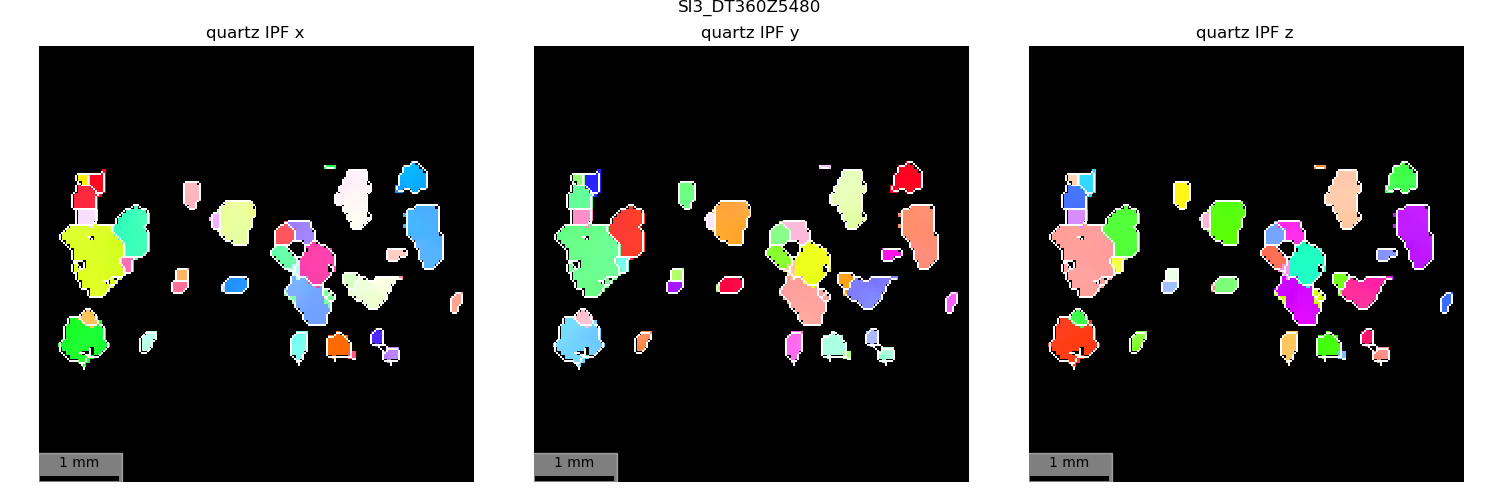

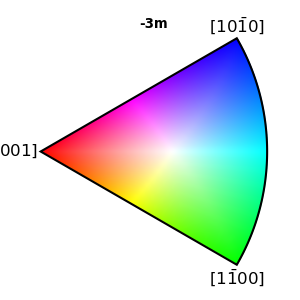

In [106]:
# segment grains with smoothed data and check grain boundaries
# add smoothed ori to xmap
xmap2 = xmap.copy()
if 'U_smooth' not in xmap2.titles():
    xmap2.add_data(np.zeros_like(xmap2.U),'U_smooth')
U_smooth = U_smooth.reshape(nx*nx,3,3)
xmap2.update_pixels('U_smooth', U_smooth[pm],selection_mask=pm)

# compute grain boundaries
xmap2.calcGrains(phase_to_denoise, Ucol='U_smooth', threshold_deg=2, min_grain_size=3)
xmap2.plot_ipf_orientation(phase=phase_to_denoise, datacolname='U_smooth', ipf_directions='xyz', show_gb=True, gb_color='w', gb_res_fact=2)

### map grain_id labels to grains dict
calcGrains updates the `grain_id` column but does not compute average grain properties neither creates new grains. For that we need to use the function `add_grains_from_map`, which will create new grains objects from the grain label map and store them in a dictionnary `xmap.grains.dict`.

In [111]:
# add grains to xmap.grains dict -> grain obj defined for each segmented domain and added to a dictionnary in xmap.grains
xmap.grains.__init__()

for phase in xmap.phases.pnames:
    
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue 
    
    xmap.add_grains_from_map(phase, Ucol='U', overwrite=False)


print(xmap.grain_id.max(), max(xmap.grains.gids))    

100%|██████████| 41/41 [00:01<00:00, 34.84it/s]

83 83


In [112]:
xmap.grains.dict

{1: <ImageD11.grain.grain at 0x15235500f9e0>,
 2: <ImageD11.grain.grain at 0x15235529a570>,
 3: <ImageD11.grain.grain at 0x1523550ba120>,
 4: <ImageD11.grain.grain at 0x1523550b8a10>,
 5: <ImageD11.grain.grain at 0x152355299fa0>,
 6: <ImageD11.grain.grain at 0x1523550b89e0>,
 7: <ImageD11.grain.grain at 0x15235500d1c0>,
 8: <ImageD11.grain.grain at 0x1523550ba990>,
 9: <ImageD11.grain.grain at 0x1523550bac30>,
 10: <ImageD11.grain.grain at 0x1523550bb0b0>,
 11: <ImageD11.grain.grain at 0x15240092ebd0>,
 12: <ImageD11.grain.grain at 0x1523550bb410>,
 13: <ImageD11.grain.grain at 0x1523551dd520>,
 14: <ImageD11.grain.grain at 0x1523550bba70>,
 15: <ImageD11.grain.grain at 0x1523556ba720>,
 16: <ImageD11.grain.grain at 0x152400b52f60>,
 17: <ImageD11.grain.grain at 0x152400b036b0>,
 18: <ImageD11.grain.grain at 0x152355122d50>,
 19: <ImageD11.grain.grain at 0x152355343260>,
 20: <ImageD11.grain.grain at 0x1523556bb050>,
 21: <ImageD11.grain.grain at 0x152400b027b0>,
 22: <ImageD11.grain.g

In [113]:
# check grain mapping is consistent: same grain labels in xmap.grain_id and grain dict
np.all(np.equal(np.unique(xmap.grain_id)[1:], np.array(sorted(xmap.grains.gids))))

True

### Grain refinement
Grain mapping simply averages the unit cell and orientation over each segmented domain, which is a bit dodgy. We need to refine grains `UBI` properly using indexed peaks. For this, we will:
1) assign peaks in peakfile to grains in pixelmap based on grain masks
2) for each grain, select peaks from the peakfile, exclude outliers and merge by unique hkl
3) fit new grain UBI using the merged g-vectors, using a similar procedure as pixel-by-pixel indexing

The refinement function returns statistics about the proportion of peaks retained and the misorientation between old and new orientation (in degree) 

In [114]:
# Sanity check: make sure grain labels are all consistent in xmap.grain_id, xmap.grains dict and peakfile

def check_grain_labels(cf, xmap):
    gids_xmap = np.unique(xmap.grain_id[xmap.phase_id != -1])
    gids_glist = np.unique(np.array(sorted(xmap.grains.gids)))
    gids_cf = np.unique(cf.grain_id)
    
    assert np.all(np.equal(gids_xmap[1:], gids_glist)), 'grain labels in xmap.grain_id and xmap.grains do not match'
    assert np.all(np.equal(gids_xmap, gids_cf)), 'grain labels in xmap and peakfile do not match'
    
    print('grain labels OK')

In [115]:
# load peakfile
cf = load_cf(dsname)

Reading your columnfile in hdf format
sorting peakfile by friedel pair index...
sorting peakfile by "xyi"...


In [117]:
# map peaks to grains
for pid, phase in zip(xmap.phases.pids, xmap.phases.pnames):
    # skip not indexed stuff
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue 
    # first indexed phase (quartz): initialize grains dict
    if pid == 0:
        xmap.map_pks_to_grains(phase, cf, overwrite=True)
    # other phases: update grain dict
    else:
        xmap.map_pks_to_grains(phase, cf, overwrite=False)

peaks to grains mapping...


100%|██████████| 35/35 [00:00<00:00, 804.22it/s]


completed
peaks to grains mapping...


100%|██████████| 6/6 [00:00<00:00, 1219.45it/s]


completed
peaks to grains mapping...


100%|██████████| 40/40 [00:00<00:00, 1259.42it/s]

completed


In [118]:
# grain ids have been added to peakfile. We can check unique grain ids in poeakfile match those in pixelmap
check_grain_labels(cf, xmap)

grain labels OK


Now we can refine each grain `UBI` using all peaks assigned from the grain mask. 

**Notes**
- use large hkl tolerance here, because we want the "average" orientation of grains that can show large intra-granular orientation spread. If hkltol is too small, it will filter out most of the peaks from the grain 
- nmedian is an additional parameter to exclude outliers gvectors plotting too far away from the median of all g-vectors in the selection

In [119]:
# refine grain ubis based on all peaks mapped to each grains 
stats = {}
for pid, phase in zip(xmap.phases.pids, xmap.phases.pnames):
    # skip not indexed stuff
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue 
    cs = xmap.phases.get(phase)
    stats[phase] = xmap.refine_grain_ubis(phase, cf, hkl_tol=.5, nmedian=10, sym = cs.orix_phase.point_group.laue)

refining ubis...


100%|██████████| 35/35 [00:00<00:00, 179.99it/s]


refining ubis...


100%|██████████| 6/6 [00:00<00:00, 508.09it/s]


refining ubis...


100%|██████████| 40/40 [00:00<00:00, 332.23it/s]


`refine_grain_ubis` returns some statistics about refinement for each grain, stored in a dict: 
- `completeness`: similar to `indexing_completeness` in local indexing = fraction of indexed intensity but this time over the whole grain mask
- `mean_drlv2`  : mean deviation from hkl integer for all g-vectors used in the refinement
- `angle deviation` : rotation between older (non-refined) and new orientation matrix, in degree 

In [120]:
stats['quartz']

{'completeness': [0.9833647859107406,
  0.9846425524068753,
  0.9930778863337693,
  0.985377829454682,
  0.9848190197505716,
  0.9611551589374521,
  0.9080845624142287,
  0.8550117274588833,
  0.9617445480728791,
  0.9797218292899861,
  0.9711044433234972,
  0.9519456609039461,
  0.9771743906491182,
  0.9141509013212625,
  0.9286292211015679,
  0.9639889711496582,
  0.9734598841185792,
  0.9774550649694145,
  0.932439592291222,
  0.8606958396627425,
  0.9528281187091953,
  0.9919818505873405,
  0.9255935615863464,
  0.9856318418813911,
  0.9946685506586976,
  0.9205549354183433,
  0.9669828195799582,
  0.8199644502753212,
  0.9832658457923936,
  0.8616191324389031,
  0.8729060417008319,
  0.9731349065234106,
  0.9028074125347765,
  0.9823639390810583,
  0.9142397552004683],
 'nindx': [104,
  170,
  136,
  130,
  156,
  122,
  144,
  152,
  200,
  140,
  174,
  128,
  220,
  144,
  162,
  130,
  166,
  124,
  148,
  156,
  158,
  162,
  138,
  170,
  154,
  172,
  156,
  122,
  162,
  1

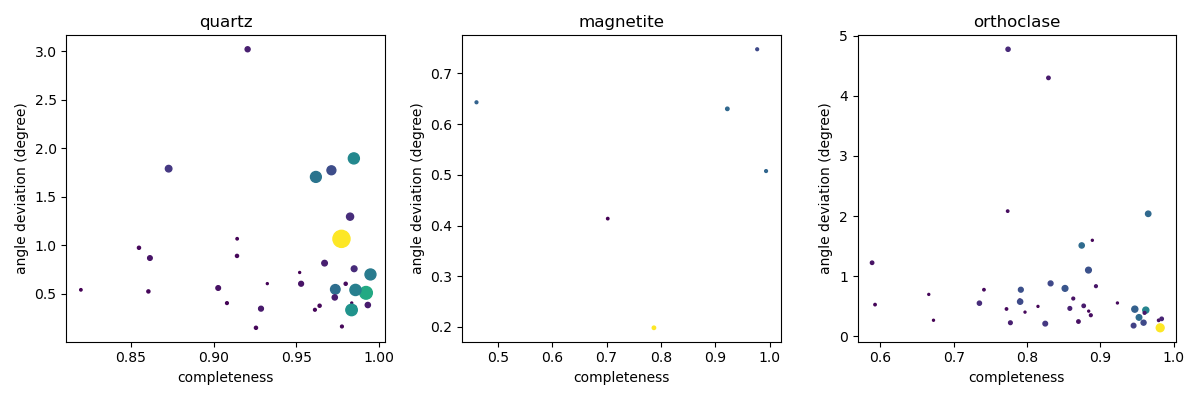

In [121]:
# let's plot these per grain
N = len(stats)

fig = pl.figure(figsize=(4*N,4))
for i,(pname,stat) in enumerate(stats.items()):
    ax = fig.add_subplot(1,N,i+1)
    ax.scatter(stat['completeness'], stat['angle deviation'],
           s=xmap.grains.get_all('grainsize', pname),
           c=xmap.grains.get_all('TotalIntensity', pname))
    ax.set(xlabel='completeness', ylabel='angle deviation (degree)')
    ax.set_title(pname)
fig.tight_layout()

### Misorientation
Now that we have grains with refined orientation, we can compute compute misorientation metrics: Kernel average misorientation + Deviation from Mean grain orientation (GROD / Intragranular Misorientation)

In [122]:
# GROD: Grain Reference Orientation Deviation (see https://mtex-toolbox.github.io/EBSDGROD.html)
# returned as axis-angle orientation per pixel
xmap.calcGROD(pixel_orientation='U')

Computing GROD: 100%|██████████| 81/81 [00:02<00:00, 30.54it/s]


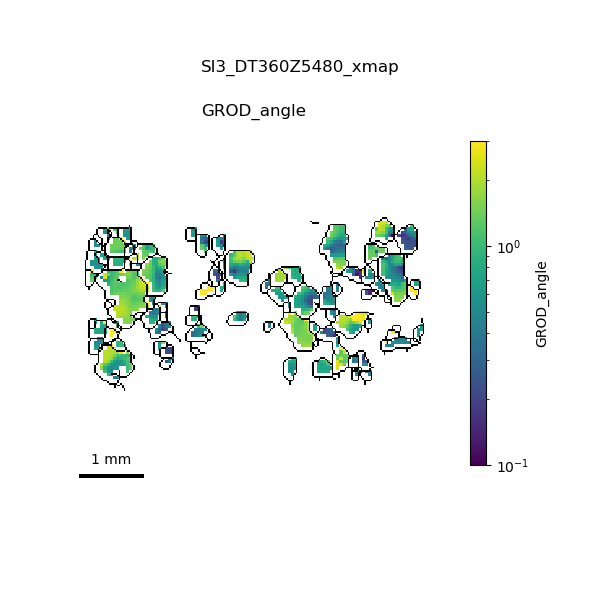

In [123]:
# plot GROD angle. also called "Mis2Mean" in MTex: Hiow much each pixel deviates from its mean grain orientation
norm=pl.matplotlib.colors.LogNorm(vmin=.1, vmax=3)
pl.close('all')

fig = xmap.plot('GROD_angle', norm=norm, out=True)

for phase in xmap.phases.pnames:
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue 
    k = xmap.phases.get(phase).orix_phase.color
    xmap.add_grain_boundaries(phase, ax=fig.axes[0], resolution_factor=2, gb_color='k')

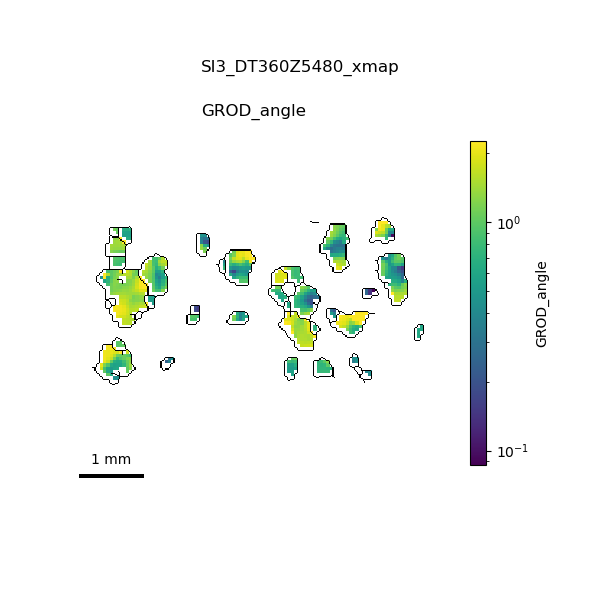

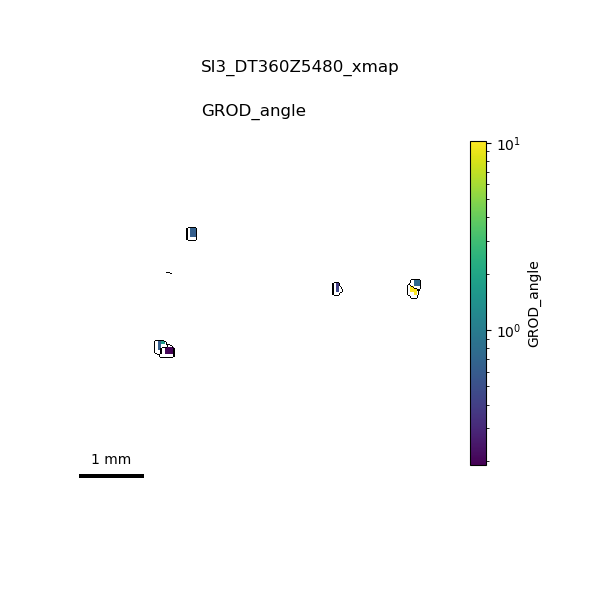

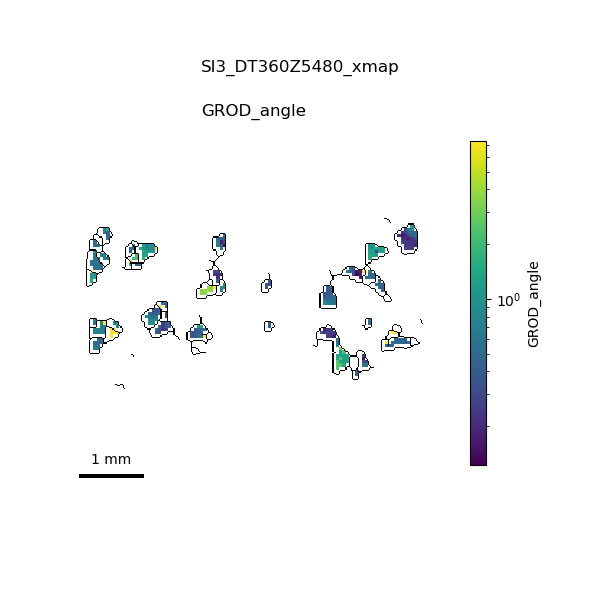

In [124]:
# same for each phase in separate plots
for phase in xmap.phases.pnames:
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue
        
    low, up = np.percentile(xmap.GROD_angle[pm & (xmap.GROD_angle>0)], (.1,95))
    xmap.plot('GROD_angle', phase=phase, show_gb=True, gb_color='k',
              norm=pl.matplotlib.colors.LogNorm(vmin=low, vmax=up))

Grain misorientation axis is also returned as a 3D vector in xyz sample coordinates. This can be used for further misorientation analysis and identification of slip systems (plastically deformed grains)

In [127]:
xmap.GROD_axis_xyz[xmap.GROD_angle>0]

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       ...,
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

**Kernel Average Misorientation**

Local Misorientation is computed with the `calcKAM` function. Takes all pixels in local neighborhood and computes average misorientation. This has to be run phase by ^phase 
- kernel size : controls size of the neighborhood
- threshold_deg: exclude neighbors with too large misorientation (likely from different grains)
- use_numba_acceleration: fast mode to calculate misorientation by simple U matrix comparison, but ignores crystal symmetry
- mode: 'mean' or 'median' misorientation

In [128]:
# Kernel Average Misorientation
for phase in xmap.phases.pnames:
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue
    xmap.calcKAM(phase, Ucol='U', kernel_size=3, threshold_deg=2, use_numba_acceleration=False, mode='mean')

Orix symmetry-accurate mode (slower)...


100%|██████████| 108/108 [00:06<00:00, 16.66it/s]


Orix symmetry-accurate mode (slower)...


100%|██████████| 108/108 [00:06<00:00, 16.82it/s]


Orix symmetry-accurate mode (slower)...


100%|██████████| 108/108 [00:06<00:00, 16.75it/s]


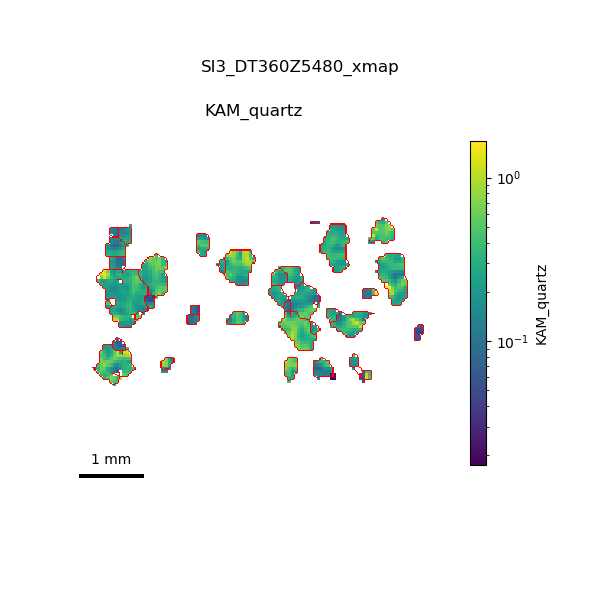

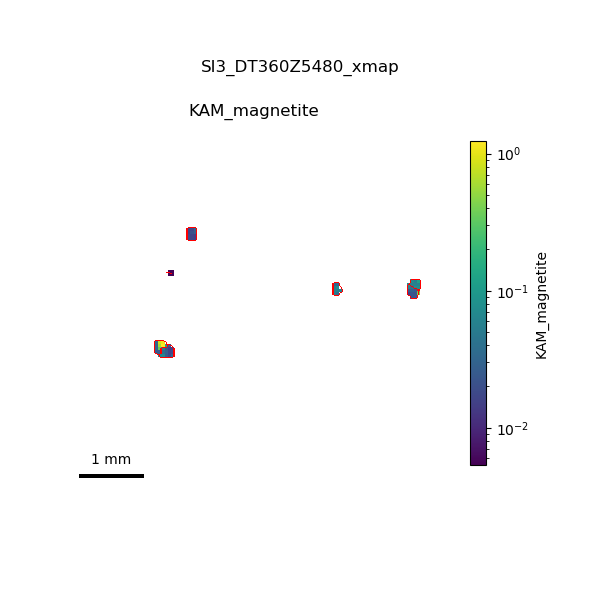

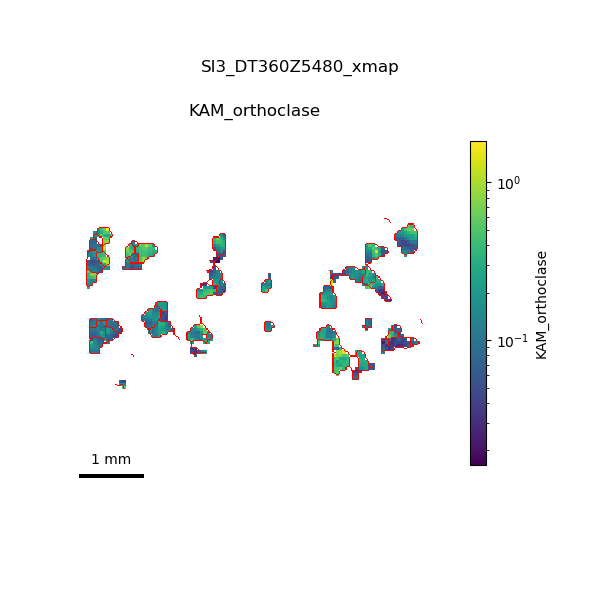

In [130]:
for phase in xmap.phases.pnames:
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue
    xmap.plot(f'KAM_{phase}', phase=phase, show_gb=True, gb_color='r', autoscale=False, norm=pl.matplotlib.colors.LogNorm())

KAM is computed phase by phase and stored in different columns `KAM_<phase>`. It saves space to merge them into one single array.

In [131]:
# plot all KAM combined
KAM_merged = np.zeros_like(xmap.KAM_quartz)

for phase in xmap.phases.pnames:
    if f'KAM_{phase}' in xmap.titles():
        pm = xmap.get_phase_mask(phase)
        KAM_merged[pm] = xmap.get(f'KAM_{phase}')[pm]

xmap.add_data(KAM_merged,'KAM')

# delete former KAM_<phase> arrays
for p in xmap.phases.pnames:
    if f'KAM_{p}' in xmap.titles():
        delattr(xmap, f'KAM_{p}')

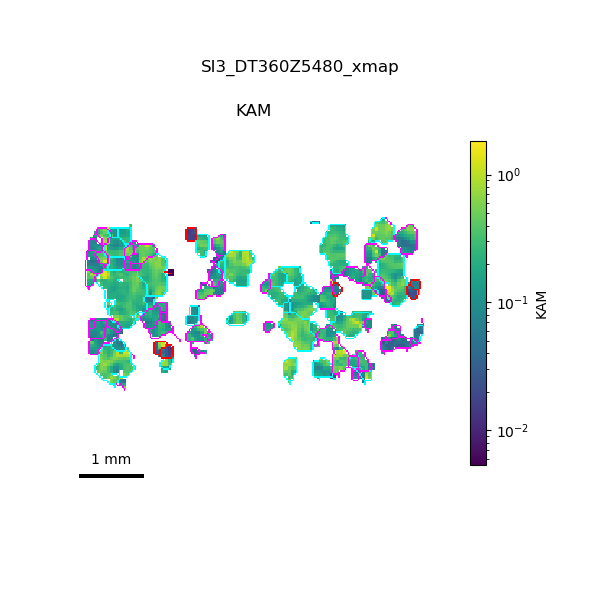

In [132]:
fig = xmap.plot('KAM', norm=pl.matplotlib.colors.LogNorm(), out=True)

for i, phase in enumerate(xmap.phases.pnames):
    pm = xmap.get_phase_mask(phase)
    if (phase =='notIndexed') or (xmap.nindx[pm].max() <= 0):
        continue
    xmap.add_grain_boundaries(phase, ax=fig.axes[0], resolution_factor=2, gb_color=gb_col[i])

### Save refined map and peakfile
We need to save the peakfile with new grain_id and the map with refined grains and misorientation (KAM, GROD)

In [133]:
pksfile = os.path.join(data_dir, f'{dsname}_pk2d_p_flt.h5')

In [134]:
utils.colf_to_hdf(cf, pksfile, save_mode='minimal')        
xmap.save_to_hdf5()

Pixelmap saved to: /home/esrf/jean1994b/test_datasets/SI3/SI3_DT360Z5480_xmap.h5


### Export to MTex .ctf File

There is a built-in method in ImageD11 `TensorMap` that we can use that to create a .ctf file that can be read in Mtex

In [173]:
# first convert xmap to TensorMap
tmap = xmap.to_tensor_map()

In [174]:
# xmap puts zeros 3x3 matrices as default 'notIndexed' orientation. Change to np.nan 
m = tmap.nindx <= 0
tmap.U[m] = np.nan

In [175]:
# then export to ctf
ctf_path = xmap.h5name.replace('.h5','.ctf')
tmap.to_ctf_mtex(ctf_path)

CTF exported!
In MTEX, run the command:
import_wizard('EBSD')
Click the '+', choose file /home/esrf/jean1994b/test_datasets/SI3/SI3_DT360Z5480_xmap.ctf and click 'Open'
Click 'Next >>'
Click 'Next >>' though the phases, changing if necessary (should be right though)
Choose 'apply rotation to Euler angles and spatial coordinates' with an angle of [0,0,0]
Choose the default MTEX plotting convention (X east, Y north)
Click 'Next >>' then 'script (m-file)' for the 'Import to', then 'Finish'
Click 'Run' at the top, save the import script somewhere, then it should run
Your EBSD should now be imported into MTEX. You can try to plot it with 'plot(ebsd)'
